In [1]:
import os, json, pandas as pd, numpy as np, joblib, matplotlib.pyplot as plt
import thermoift.PLOT_SETTINGS as ps
from thermoift import MLPostprocessing, plot_correlation_heatmap

In [2]:
PLOT_FOLDER = "TabPFN_interfacial_thickness_OUTPUTS"
target      = "interfacial_thickness"

In [3]:
with open(os.path.join(PLOT_FOLDER, f"TabPFN_{target}_metrics.json")) as f:
    metrics = json.load(f)

features     = metrics["features"]
cv_r2_mean   = metrics["cv_r2_mean"]
cv_rmse_mean = metrics["cv_rmse_mean"]
cv_mae_mean  = metrics["cv_mae_mean"]

preds_df = pd.read_csv(os.path.join(PLOT_FOLDER, f"TabPFN_{target}_predictions.csv"))

print(f"Loaded artifacts from {PLOT_FOLDER}/")
print(f"Features : {features}")
print(f"CV R²    : {cv_r2_mean:.6f}  |  CV RMSE: {cv_rmse_mean:.6f}  |  CV MAE: {cv_mae_mean:.6f}")

Loaded artifacts from TabPFN_interfacial_thickness_OUTPUTS/
Features : ['temperature', 'pressure', 'z_carbon dioxide', 'z_hydrogen', 'z_nitrogen', 'z_argon', 'z_methane', 'z_oxygen', 'z_carbon monoxide', 'z_hydrogen sulfide']
CV R²    : 0.998020  |  CV RMSE: 0.027239  |  CV MAE: 0.011101


In [4]:
train_rows = preds_df[preds_df["split"] == "train"]
test_rows  = preds_df[preds_df["split"] == "test"]
val_rows   = preds_df[preds_df["split"] == "val"]

y_train      = pd.Series(train_rows["actual"].values, index=train_rows["idx"].values, name=target)
y_train_pred = train_rows["predicted"].values
y_test       = pd.Series(test_rows["actual"].values, index=test_rows["idx"].values, name=target)
y_test_pred  = test_rows["predicted"].values
y_val        = pd.Series(val_rows["actual"].values, index=val_rows["idx"].values, name=target)
y_val_pred   = val_rows["predicted"].values

post = MLPostprocessing(
    y_true=y_test,
    y_pred=y_test_pred,
    target=target,
    feature_names=features,
    datasets={
        "train": (y_train, y_train_pred),
        "test":  (y_test,  y_test_pred),
        "val":   (y_val,   y_val_pred),
    },
)

In [5]:
df = pd.read_csv("../../interfacial_results_dataset_A4.csv")
# plot_correlation_heatmap(df, features, target, save_path=f"TabPFN_{target}_correlation", folder=PLOT_FOLDER)

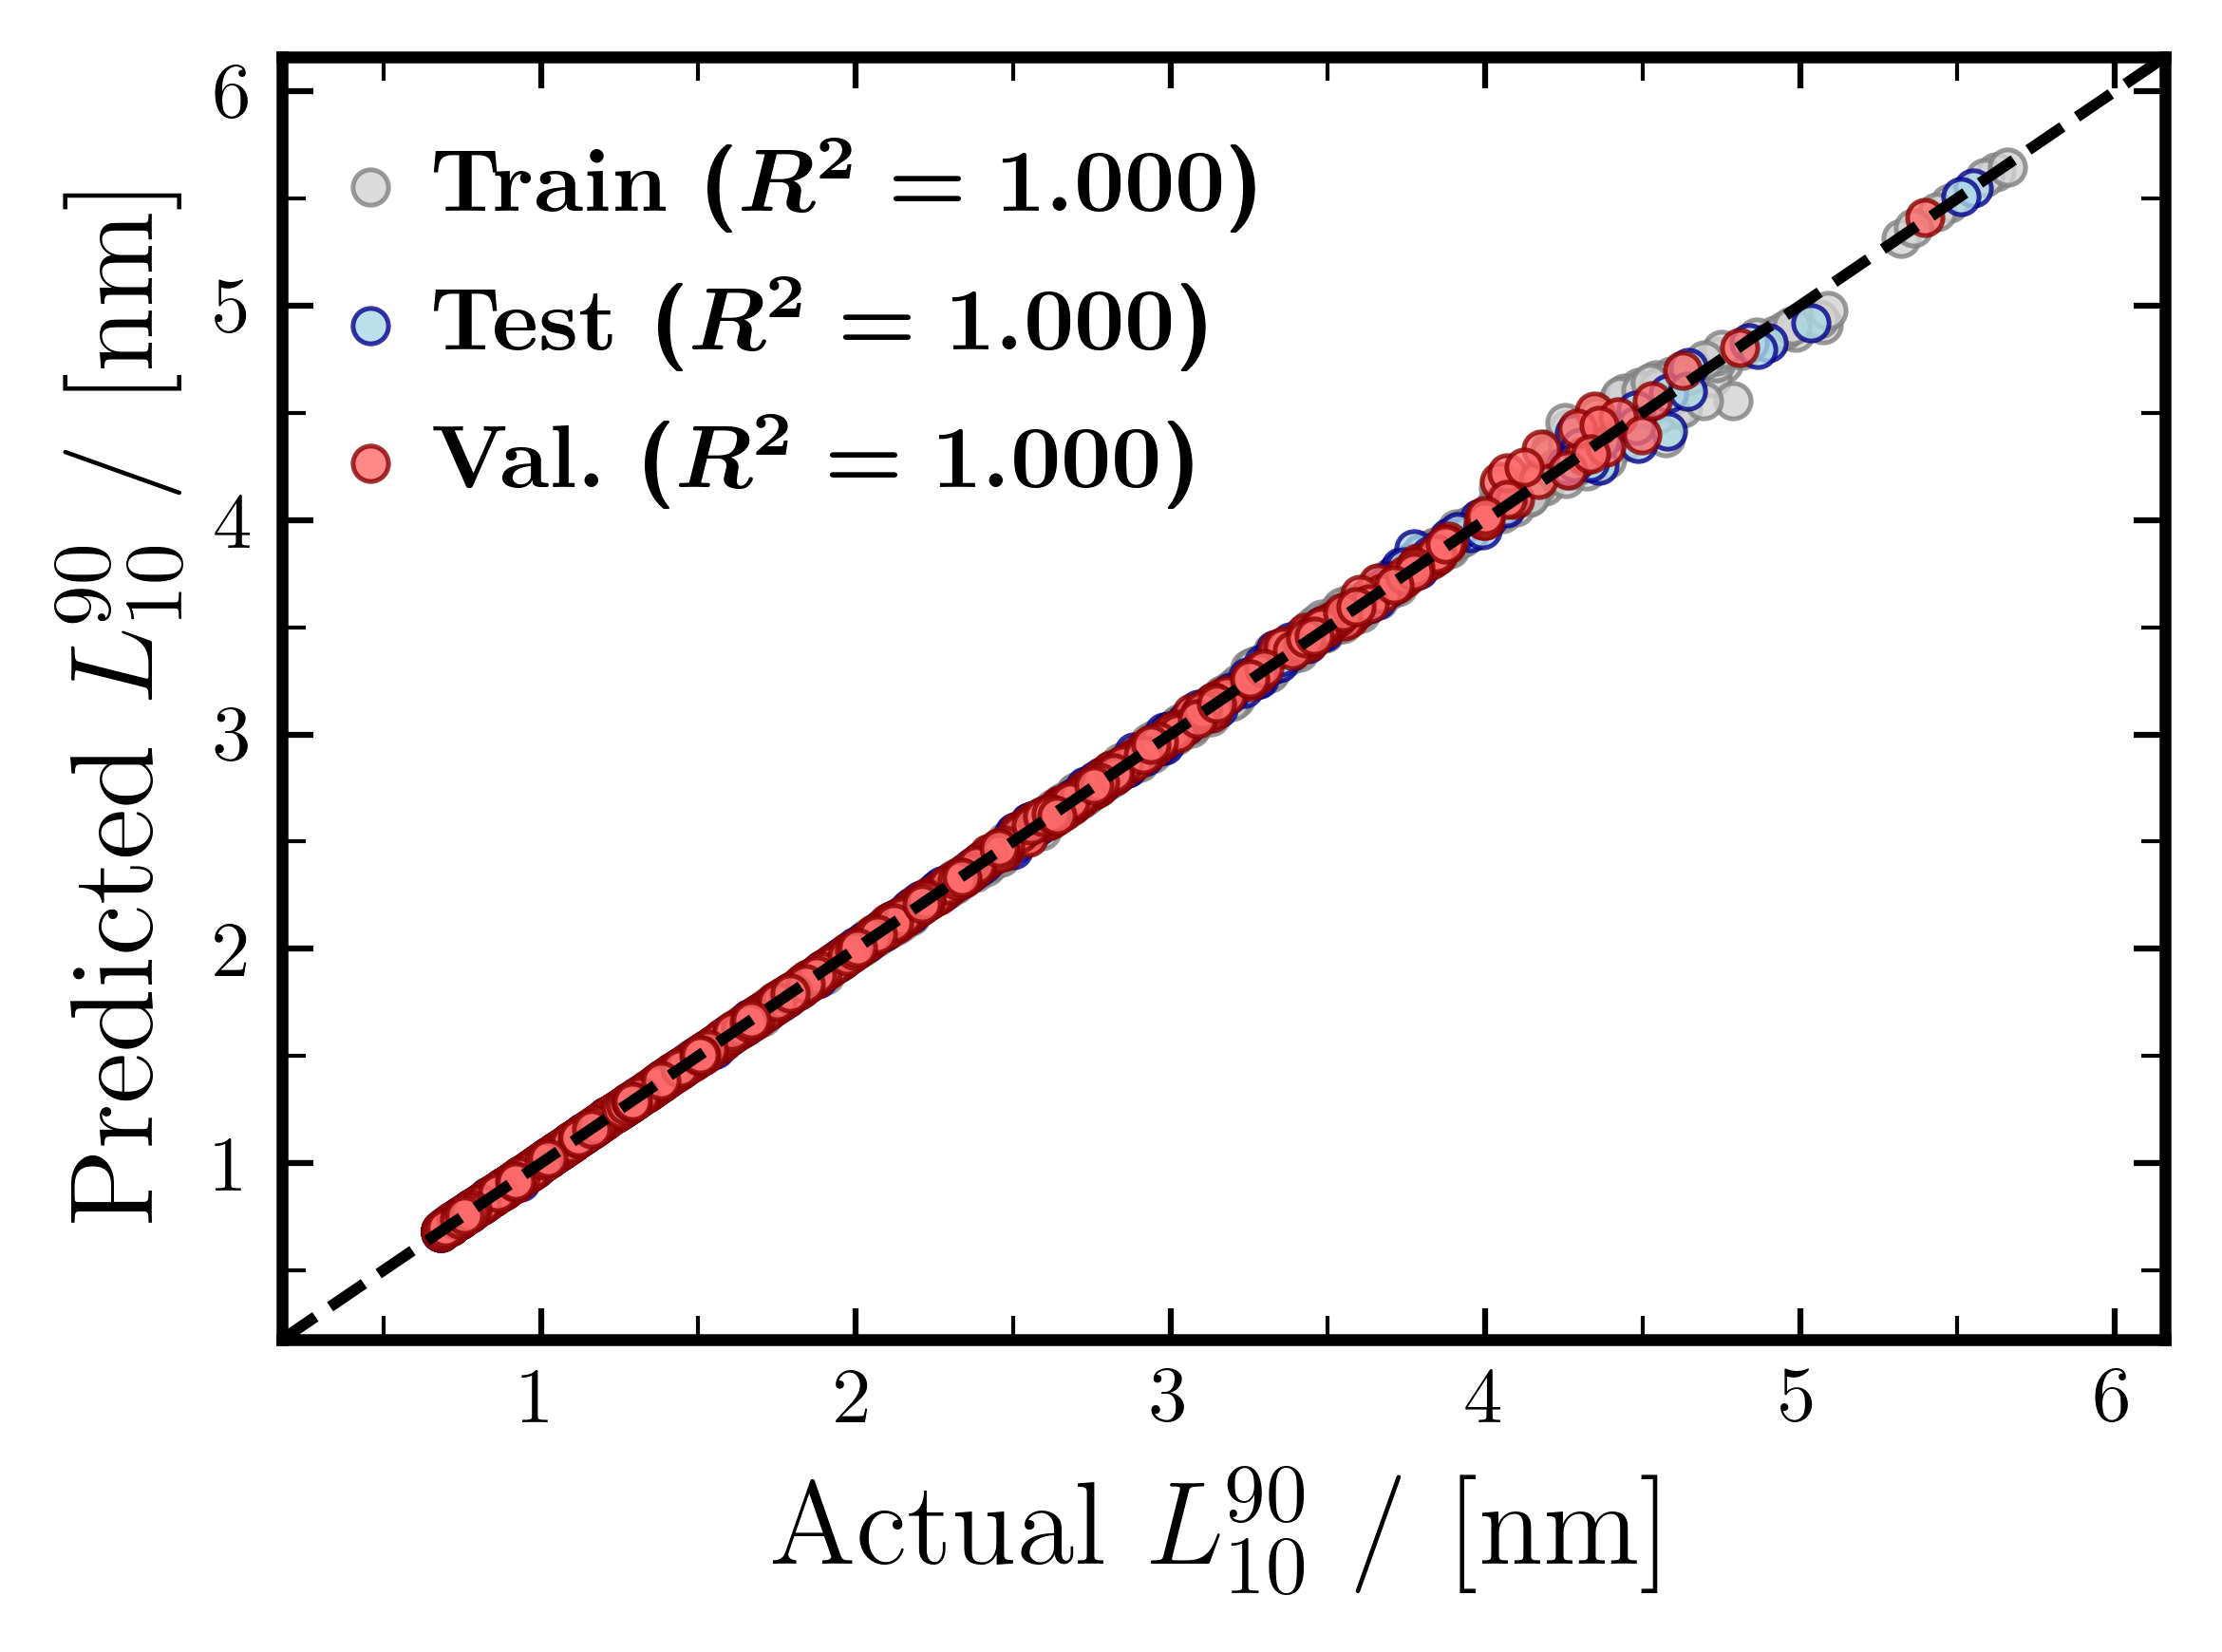

(<Figure size 2400x1800 with 1 Axes>,
 <Axes: xlabel='$\\mathrm{Actual}$ $L^{90}_{10}$ / $[\\mathrm{nm}]$', ylabel='$\\mathrm{Predicted}$ $L^{90}_{10}$ / $[\\mathrm{nm}]$'>)

In [6]:
post.plot_parity(model_name="TabPFN", save_path=f"TabPFN_{target}_parity_plot", folder=PLOT_FOLDER,legend_loc=[0.005,0.62], # legend location
legend_handletextpad=0.2, # gap between marker and text
legend_handlelength=1.0, # marker-box width (smaller -> marker closer to text)
label_fontsize=15, # x/y axis label size
labelpad=4, # gap between axis and its label (points)
decimals=3, # decimal places for R^2 in legend
)

Outlier threshold (3σ): ±0.025224
Test outliers: 42/2904 (1.45%)
Val  outliers: 30/2905  (1.03%)
Saved: TabPFN_interfacial_thickness_outliers.csv (72 rows)
  idx split  source_id  temperature  pressure   actual  predicted  residual
 3280  test         16        295.0 73.961610 3.715463   3.749991 -0.034528
 3084  test         15        295.0 71.469563 3.794276   3.842966 -0.048689
17817  test         91        290.0 59.378145 2.728288   2.757012 -0.028725
 3281  test         16        295.0 75.065648 3.757483   3.799826 -0.042343
 2113  test         10        295.0 83.216832 4.282809   4.406292 -0.123483
 3464  test         17        290.0 56.118790 2.509445   2.545212 -0.035767
14326  test         73        295.0 77.057025 4.899699   4.825895  0.073804
18589  test         95        295.0 70.970014 3.980209   4.006764 -0.026555
15097  test         77        295.0 73.009769 4.300919   4.340709 -0.039790
16080  test         82        295.0 76.160275 4.644853   4.709602 -0.064749
 3468  t

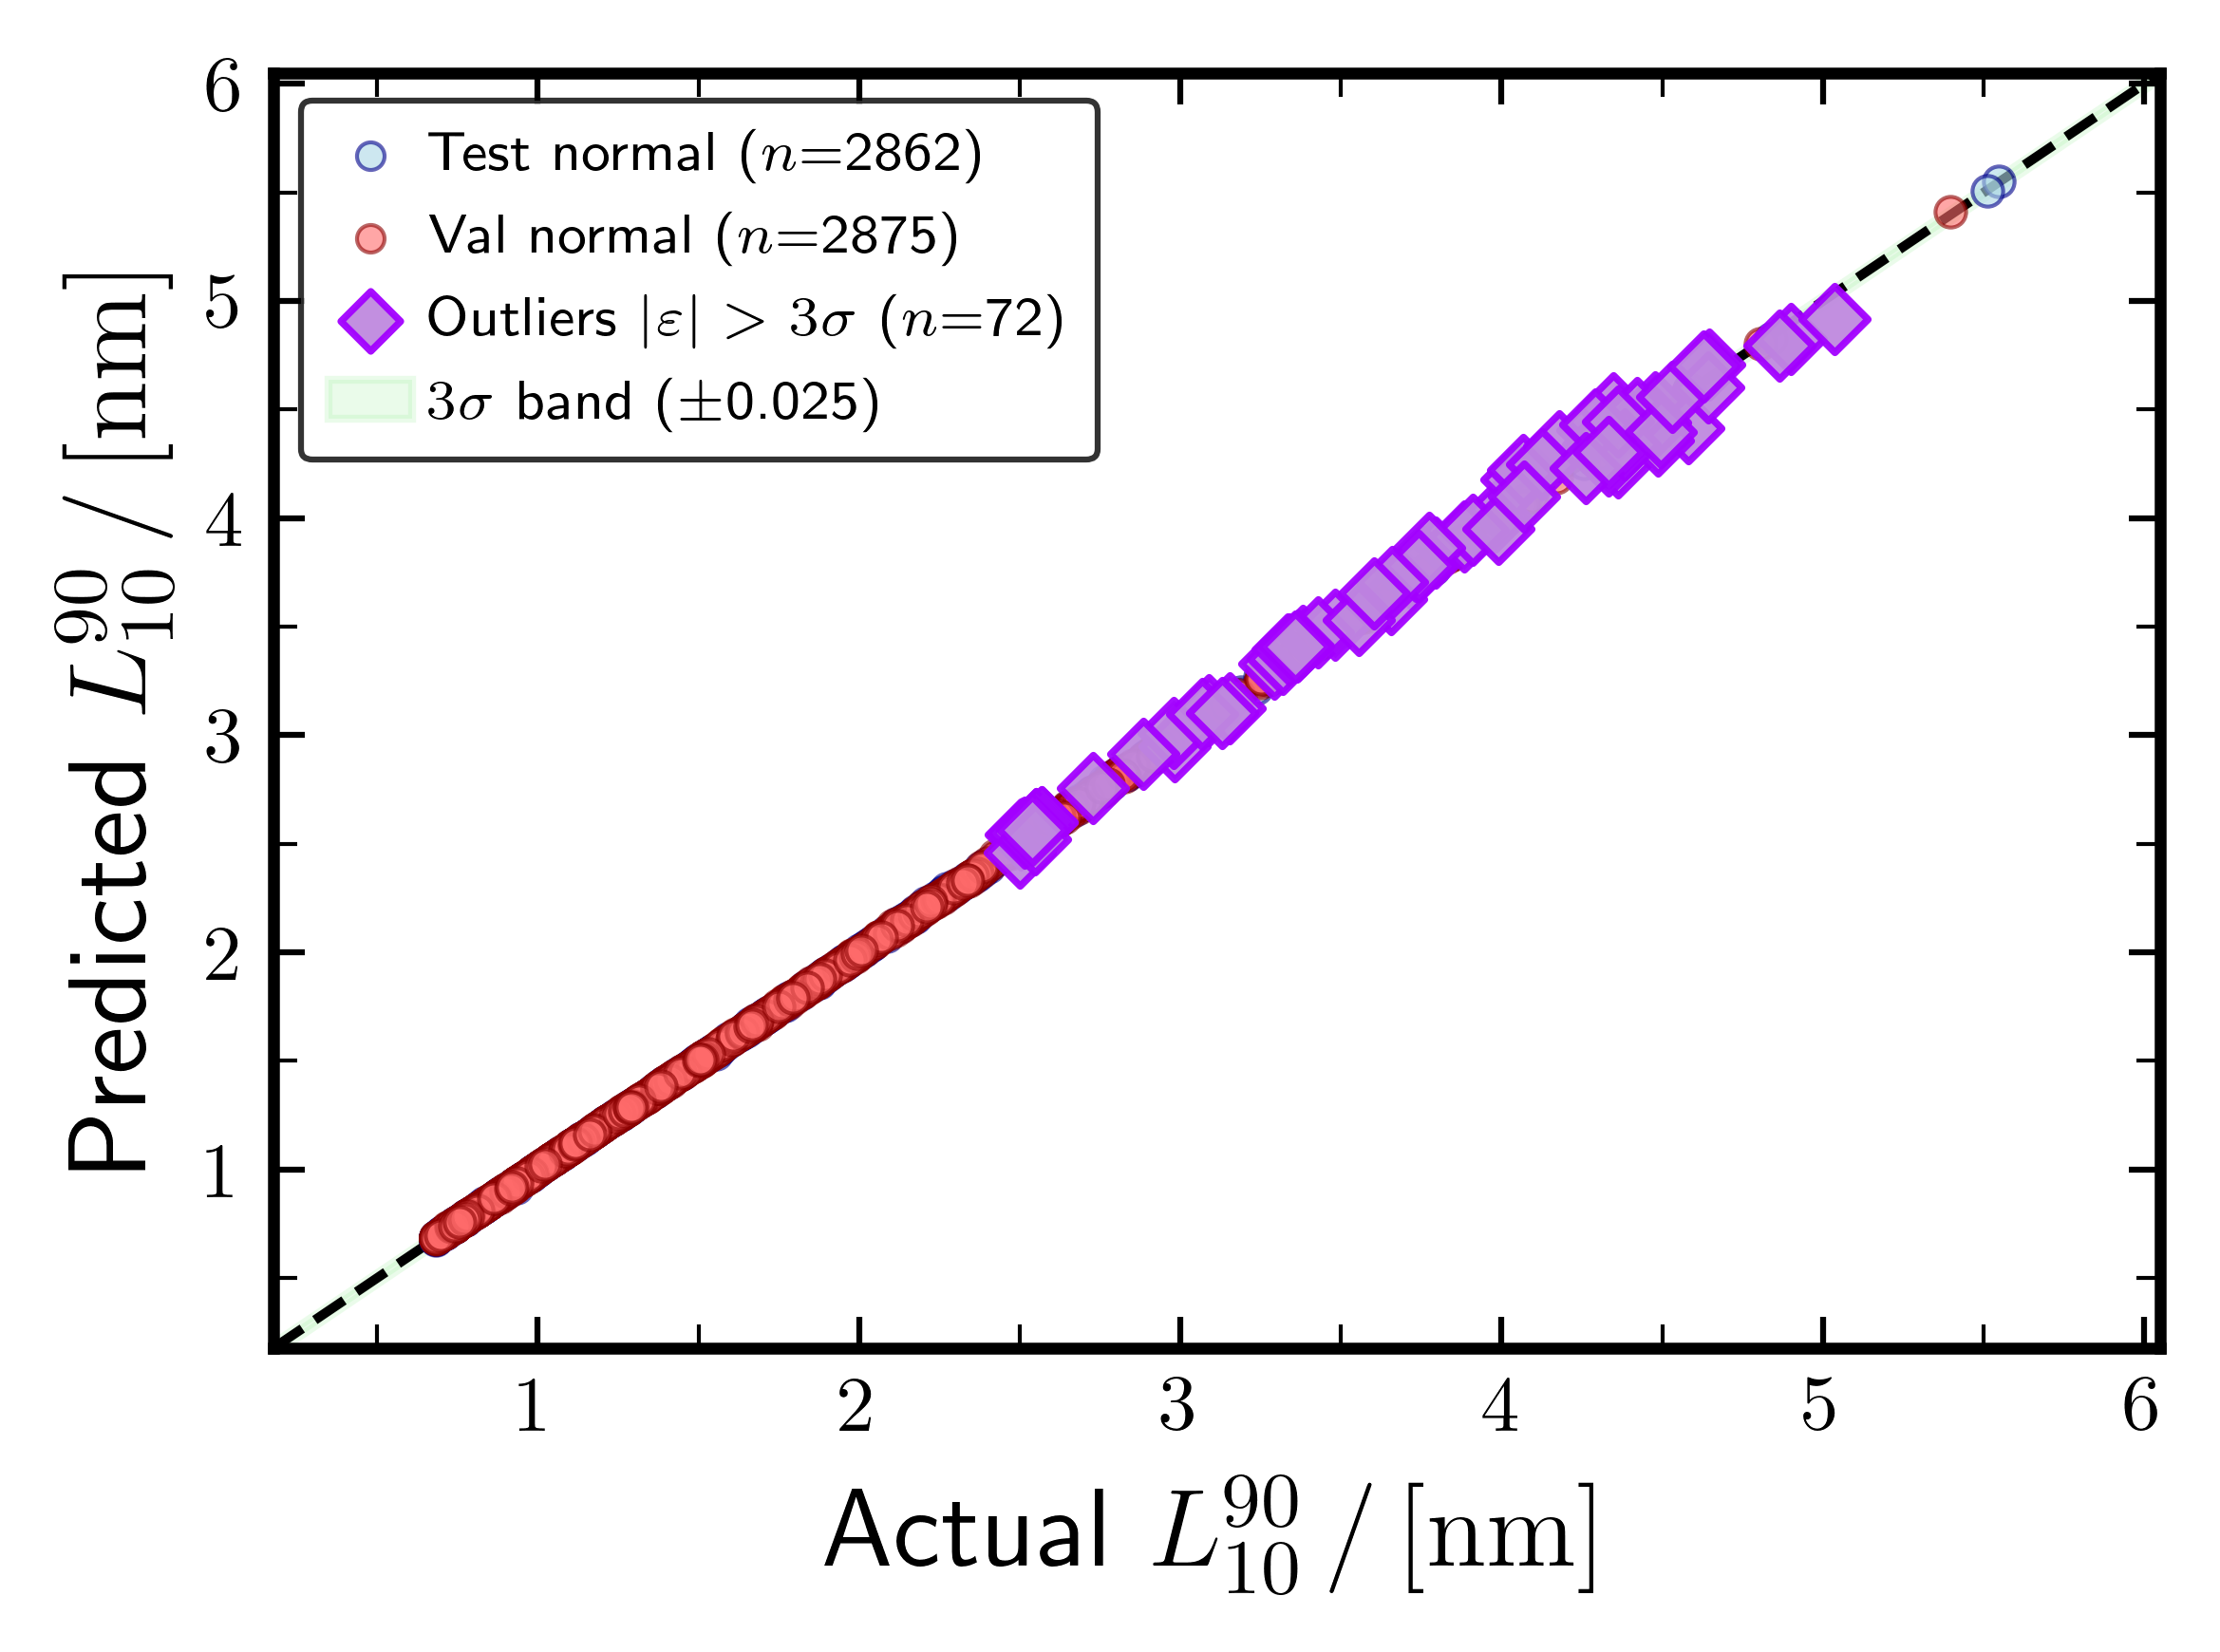

Saved: TabPFN_interfacial_thickness_outlier_parity


In [7]:
# Outlier flagging: test + val samples where |residual| > 3 * global std
from matplotlib.ticker import AutoMinorLocator

all_resids_global = np.concatenate([
    np.asarray(y_train) - y_train_pred,
    np.asarray(y_test)  - y_test_pred,
    np.asarray(y_val)   - y_val_pred,
])
threshold = 3.0 * all_resids_global.std()

test_resids   = np.asarray(y_test) - y_test_pred
val_resids    = np.asarray(y_val)  - y_val_pred
test_out_mask = np.abs(test_resids) > threshold
val_out_mask  = np.abs(val_resids)  > threshold

n_test_out = int(test_out_mask.sum())
n_val_out  = int(val_out_mask.sum())
print(f"Outlier threshold (3σ): ±{threshold:.6f}")
print(f"Test outliers: {n_test_out}/{len(y_test)} ({100*n_test_out/len(y_test):.2f}%)")
print(f"Val  outliers: {n_val_out}/{len(y_val)}  ({100*n_val_out/len(y_val):.2f}%)")

outlier_df = pd.concat([
    pd.DataFrame({
        "idx":         y_test.index[test_out_mask],
        "split":       "test",
        "source_id":   df.loc[y_test.index[test_out_mask], "source_id"].values,
        "temperature": df.loc[y_test.index[test_out_mask], "temperature"].values,
        "pressure":    df.loc[y_test.index[test_out_mask], "pressure"].values,
        "actual":      np.asarray(y_test)[test_out_mask],
        "predicted":   y_test_pred[test_out_mask],
        "residual":    test_resids[test_out_mask],
    }),
    pd.DataFrame({
        "idx":         y_val.index[val_out_mask],
        "split":       "val",
        "source_id":   df.loc[y_val.index[val_out_mask], "source_id"].values,
        "temperature": df.loc[y_val.index[val_out_mask], "temperature"].values,
        "pressure":    df.loc[y_val.index[val_out_mask], "pressure"].values,
        "actual":      np.asarray(y_val)[val_out_mask],
        "predicted":   y_val_pred[val_out_mask],
        "residual":    val_resids[val_out_mask],
    }),
], ignore_index=True)
outlier_df.to_csv(os.path.join(PLOT_FOLDER, f"TabPFN_{target}_outliers.csv"), index=False)
print(f"Saved: TabPFN_{target}_outliers.csv ({len(outlier_df)} rows)")
print(outlier_df.to_string(index=False))

# Parity plot highlighting outliers
fig, ax = ps.plot_init()

for y_true_sp, y_pred_sp, out_mask, fc, ec, lbl in [
    (y_test, y_test_pred, test_out_mask, "lightblue", "darkblue", "Test"),
    (y_val,  y_val_pred,  val_out_mask,  "#FF6B6B",   "darkred",  "Val"),
]:
    norm = ~out_mask
    ax.scatter(
        np.asarray(y_true_sp)[norm], y_pred_sp[norm],
        alpha=0.6, s=15, facecolors=fc, edgecolors=ec,
        linewidths=0.5, zorder=2,
        label=rf"{lbl} normal ($n$={int(norm.sum())})",
    )

all_out_true = np.concatenate([np.asarray(y_test)[test_out_mask], np.asarray(y_val)[val_out_mask]])
all_out_pred = np.concatenate([y_test_pred[test_out_mask], y_val_pred[val_out_mask]])
if len(all_out_true) > 0:
    ax.scatter(
        all_out_true, all_out_pred,
        alpha=0.95, s=35, facecolors="#BF89DF", edgecolors="#A200FF",
        linewidths=0.9, marker='D', zorder=4,
        label=rf"Outliers $|\varepsilon|>3\sigma$ ($n$={len(all_out_true)})",
    )
all_vals = np.concatenate([np.asarray(y_test), np.asarray(y_val), y_test_pred, y_val_pred])
lims     = [all_vals.min() - 0.5, all_vals.max() + 0.5]
x_line   = np.array(lims)
ax.fill_between(x_line, x_line - threshold, x_line + threshold,
                color="lightgreen", alpha=0.18, zorder=0,
                label=rf"$3\sigma$ band ($\pm${threshold:.3f})")
ax.plot(lims, lims, "k--", lw=1.2, zorder=1)
ax.set_xlim(lims)
ax.set_ylim(lims)

target_label_str = ps.label_map.get(target.lower(), target)
ax.set_xlabel(f"Actual {target_label_str}", fontsize=ps.label_fontsize)
ax.set_ylabel(f"Predicted {target_label_str}", fontsize=ps.label_fontsize)
ps.apply_axis_style(ax)
ax.minorticks_on()
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.tick_params(axis='both', which='minor', length=3)
ps.style_legend(ax, loc='upper left', fontsize=ps.label_fontsize * 0.5)
plt.tight_layout()
ps.save_plot(fig, f"TabPFN_{target}_outlier_parity", folder=PLOT_FOLDER)
plt.show()
print(f"Saved: TabPFN_{target}_outlier_parity")

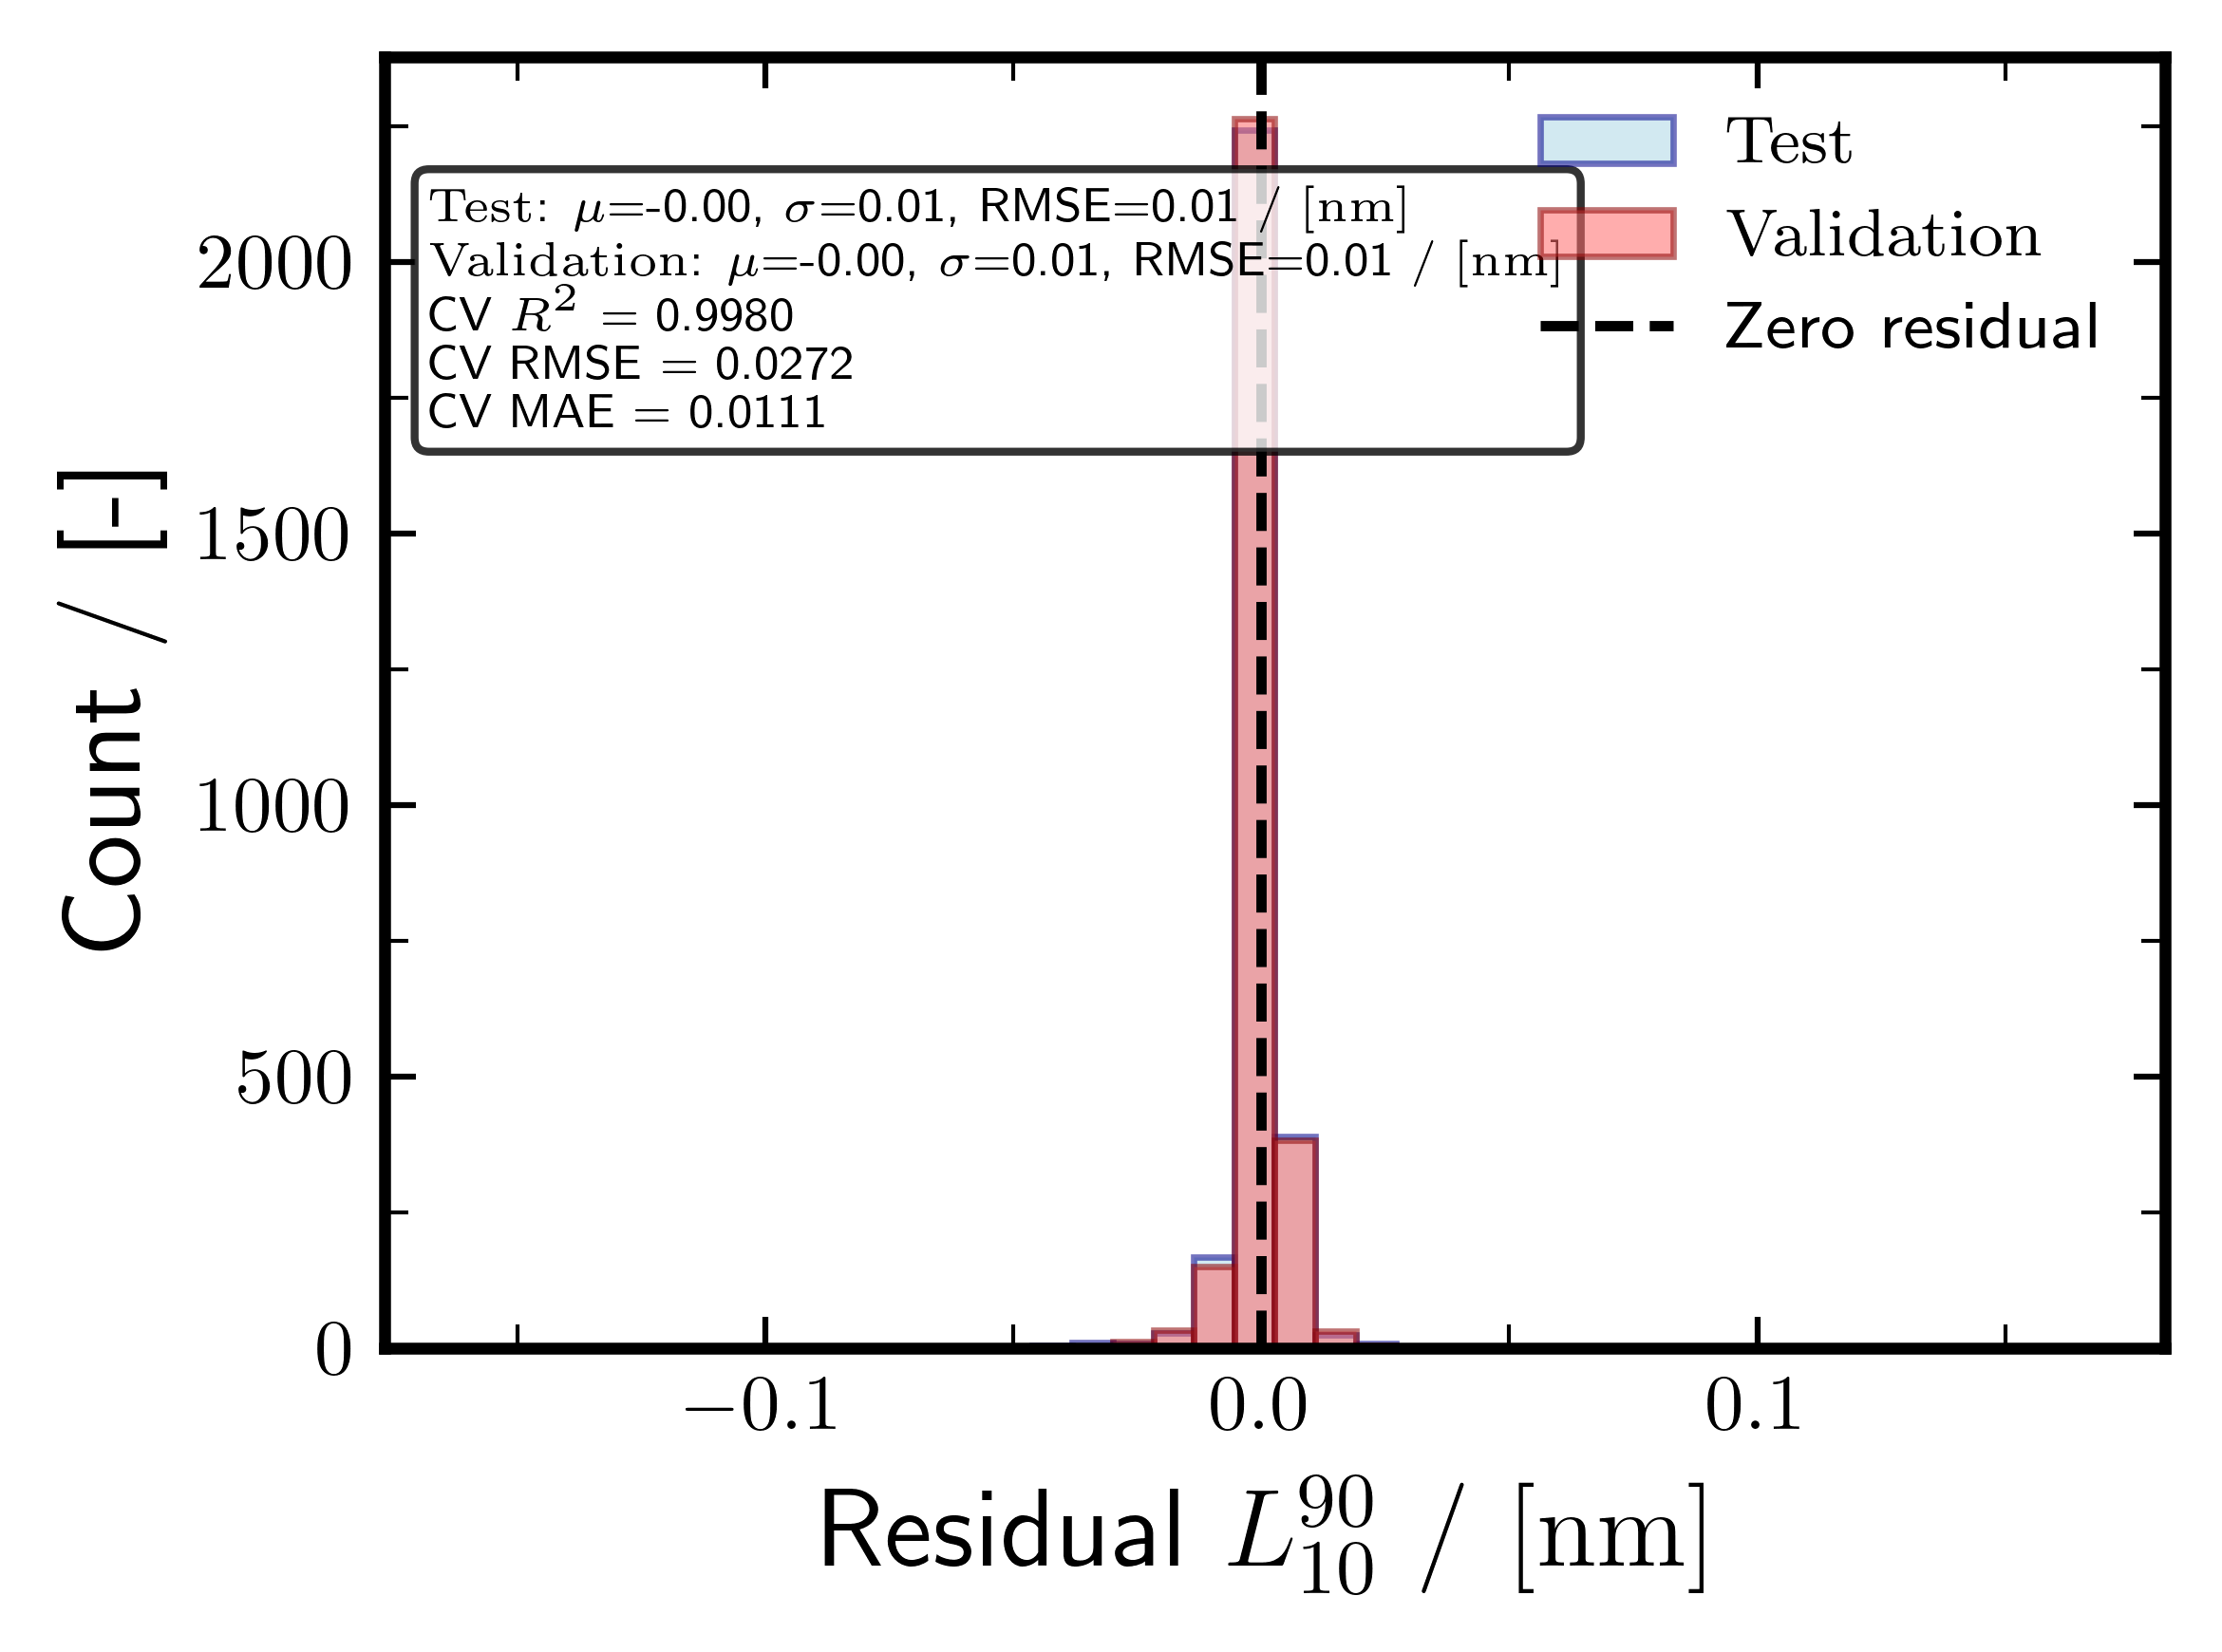

(<Figure size 2400x1800 with 1 Axes>,
 <Axes: xlabel='Residual $L^{90}_{10}$ / $[\\mathrm{nm}]$', ylabel='Count / [-]'>)

In [8]:
post.plot_residual_distribution(save_path=f"TabPFN_{target}_residual_distribution", folder=PLOT_FOLDER,
                                cv_r2=cv_r2_mean, cv_rmse=cv_rmse_mean, cv_mae=cv_mae_mean)

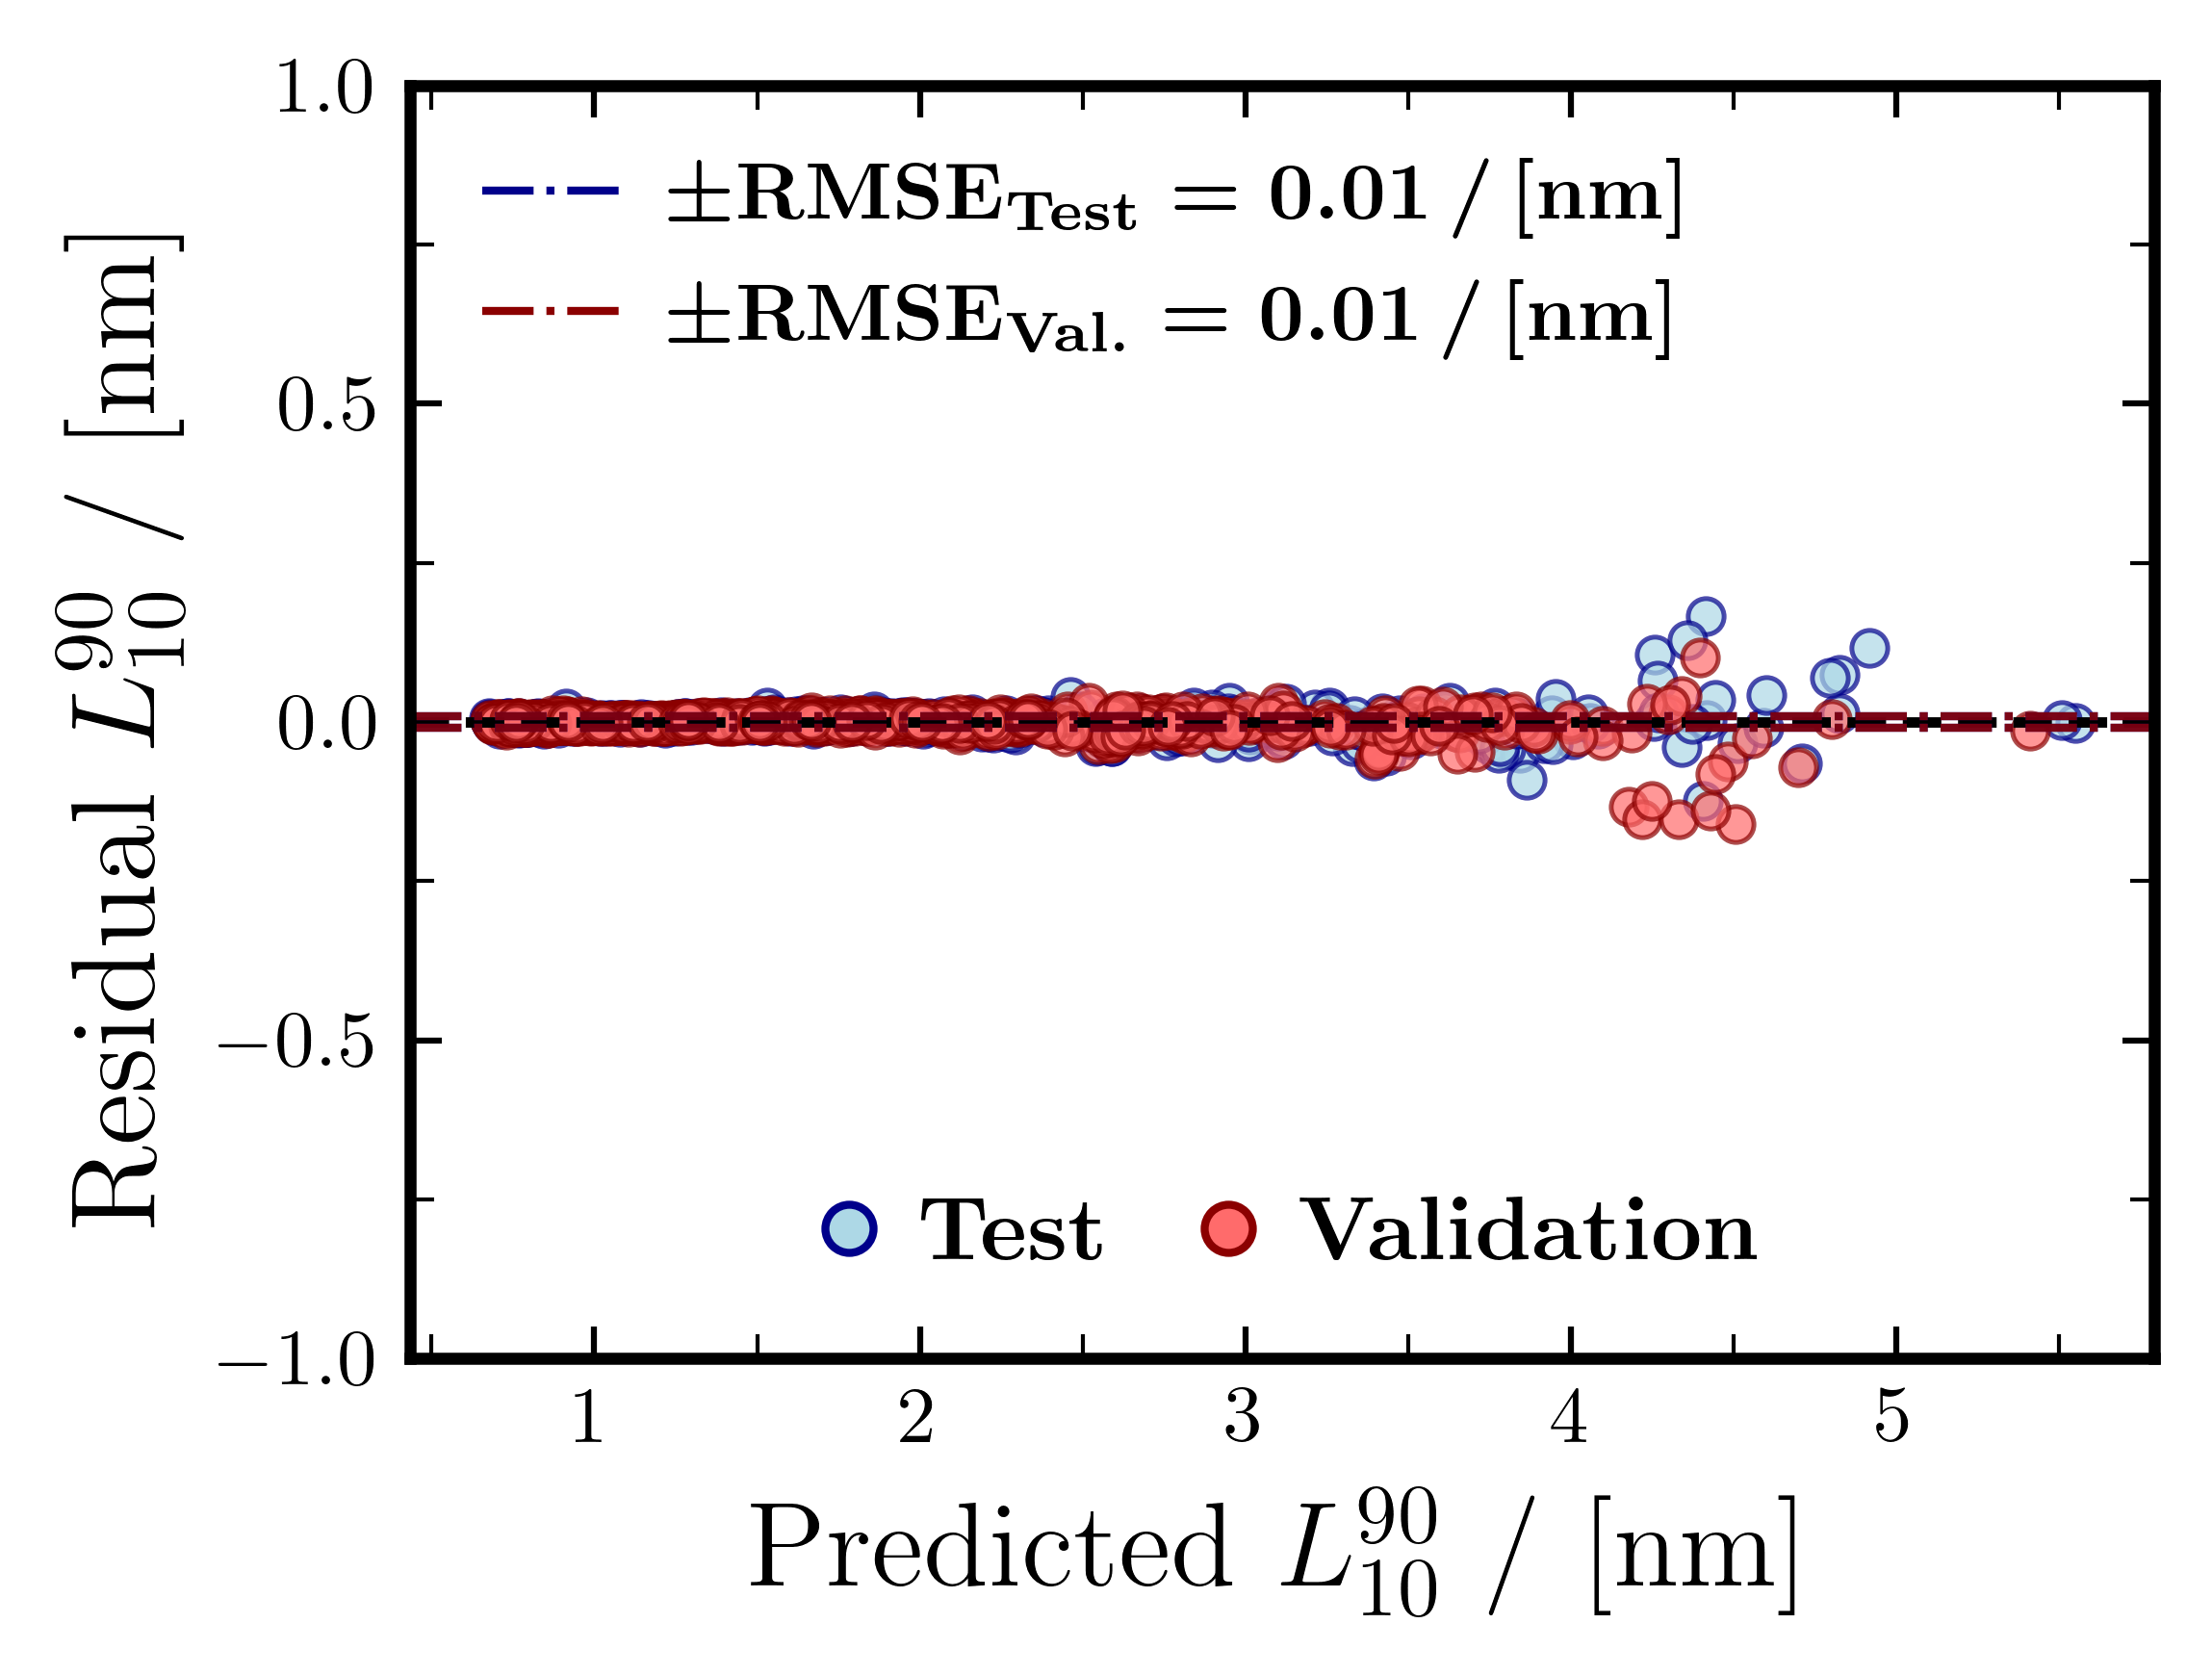

(<Figure size 2400x1800 with 1 Axes>,
 <Axes: xlabel='$\\mathrm{Predicted}$ $L^{90}_{10}$ / $[\\mathrm{nm}]$', ylabel='$\\mathrm{Residual}$ $L^{90}_{10}$ / $[\\mathrm{nm}]$'>)

In [9]:
post.plot_residual_vs_predicted(save_path=f"TabPFN_{target}_residual_vs_predicted", folder=PLOT_FOLDER,
                                y_range=[-1,1],legend_loc="lower center", # Test/Validation marker-legend location
legend_handletextpad=0.3, # gap between marker and text
legend_handlelength=1.0, # marker-box width (smaller -> marker closer to text)
label_fontsize=15, # x/y axis label size
labelpad=4, # gap between axis and its label (points)
decimals=2, # decimal places for RMSE in legend
)

In [10]:
post.print_summary()

MODEL PERFORMANCE SUMMARY - INTERFACIAL_THICKNESS
Samples:        2904
R² Score:       0.999850
RMSE:           0.008434
MAE:            0.003614
Mean Residual:  -0.000732
Std Residual:   0.008403
